#### Actividad en Clase 1

##### Parte 1

Utilizando OpenCV:

1. Carga la imagen "gato.webp" a color.
2. Separa los canales R, G, B.
3. Muestra en un histograma los valores de cada canal por separado.
4. Transforma la imagen a:
- Escala de grises
- HSV
- YCbCr
5. Muestra el histograma en los canales de luminancia (grises, V, Y) respectivamente

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

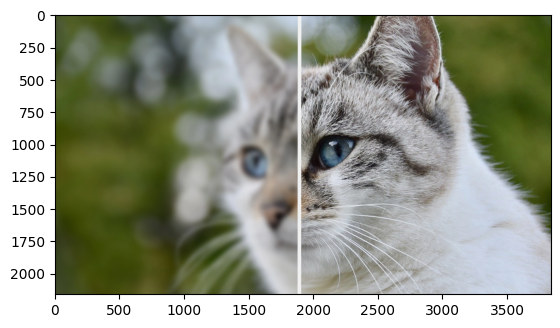

In [62]:
gato_img = cv2.imread("gato.webp")
gato_rgb = cv2.cvtColor(gato_img, cv2.COLOR_BGR2RGB)
plt.imshow(gato_rgb)

In [20]:
R, G, B = cv2.split(gato_rgb)
R.shape, G.shape, B.shape

((2160, 3840), (2160, 3840), (2160, 3840))

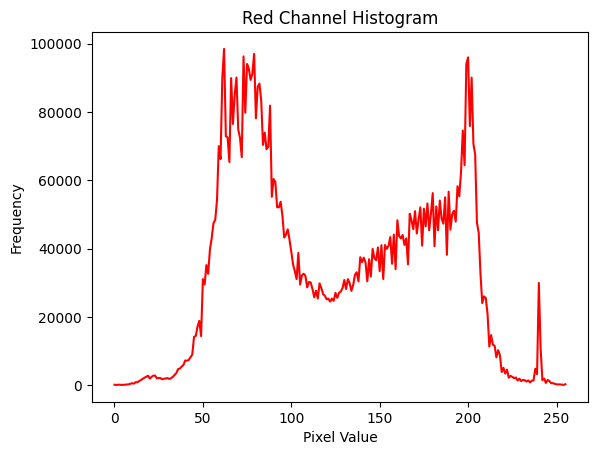

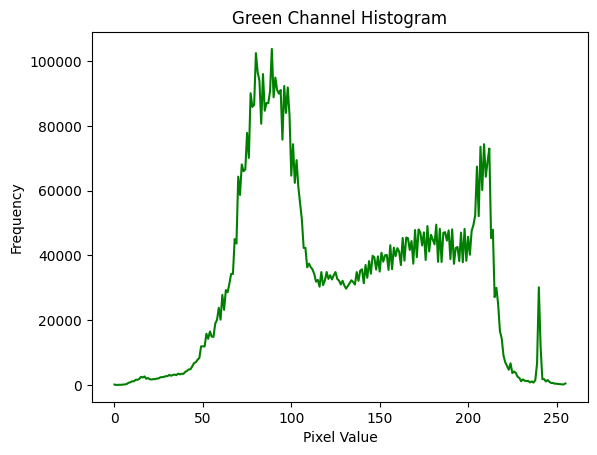

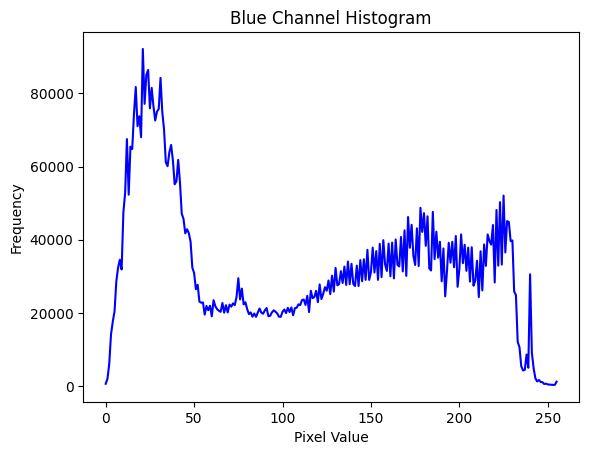

In [21]:
def hist_256(channel, plot=True, title="Histogram", color="blue"):
    hist = np.bincount(channel.ravel(), minlength=256)

    if plot:
        plt.plot(hist, color=color)
        plt.title(title)
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")
        plt.show()


hist_256(R, title="Red Channel Histogram", color="red")
hist_256(G, title="Green Channel Histogram", color="green")
hist_256(B, title="Blue Channel Histogram", color="blue")

In [22]:
# Image transformations
gray_img = cv2.cvtColor(gato_rgb, cv2.COLOR_RGB2GRAY)

hsv_imge = cv2.cvtColor(gato_rgb, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(hsv_imge)

ycbcr = cv2.cvtColor(gato_rgb, cv2.COLOR_RGB2YCrCb)
Y, Cr, Cb = cv2.split(ycbcr)

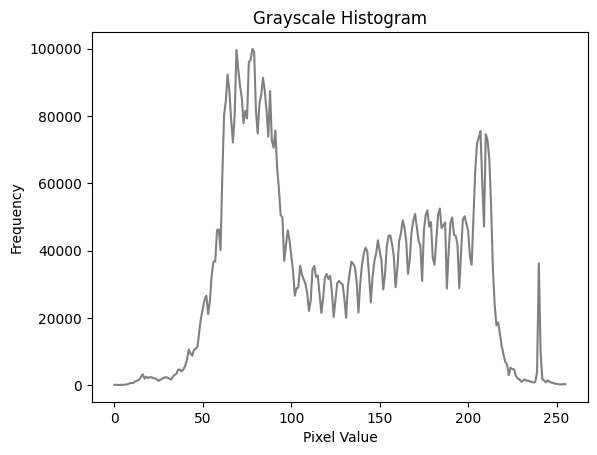

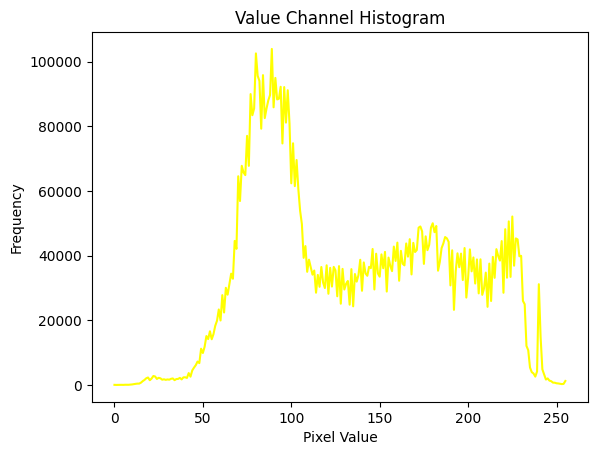

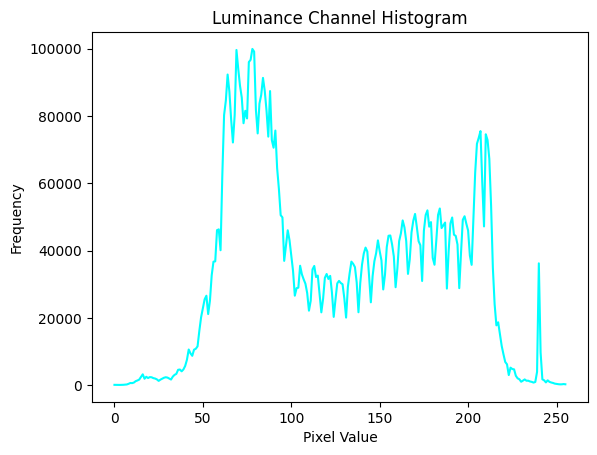

In [23]:
hist_256(gray_img, title="Grayscale Histogram", color="gray")
hist_256(V, title="Value Channel Histogram", color="yellow")
hist_256(Y, title="Luminance Channel Histogram", color="cyan")

##### Parte 2

Usando OpenCV: 

1. Aplica los siguientes filtros sobre la imagen "gato.webp" en escala de grises:

- Suavizado (blur): Promedio y Gaussiano
- Sharpen
- Detección de bordes (Sobel X, Y)
- High-Pass

2. Crea una grilla comparativa 2×3 (original + 5 filtradas)

3. Responde a la pregunta: ¿Que filtro te parece que conserva mejor los detalles? ¿Cuál reduce el ruido?

In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

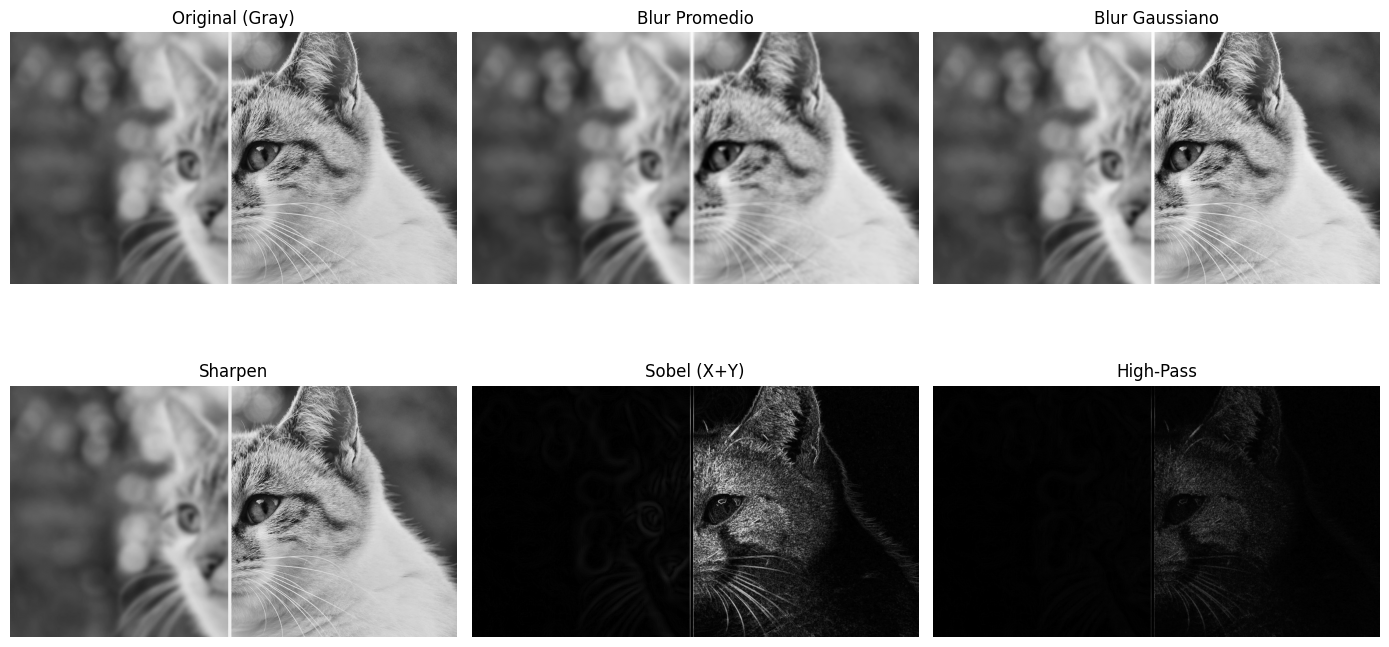

In [61]:
kernel_size = (25, 25)
blur_avg = cv2.blur(gray_img, kernel_size)
blur_gauss = cv2.GaussianBlur(gray_img, kernel_size, 1.5)

kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
sharpen_img = cv2.filter2D(gray_img, -1, kernel_sharpen)

sobel_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.convertScaleAbs(np.sqrt(sobel_x**2 + sobel_y**2))

kernel_highpass = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32)
highpass_img = cv2.filter2D(gray_img, cv2.CV_64F, kernel_highpass)
highpass_img = cv2.convertScaleAbs(highpass_img)

images = [gray_img, blur_avg, blur_gauss, sharpen_img, sobel_mag, highpass_img]
titles = [
    "Original (Gray)",
    "Blur Promedio",
    "Blur Gaussiano",
    "Sharpen",
    "Sobel (X+Y)",
    "High-Pass",
]

plt.figure(figsize=(14, 8))
for i, (img, title) in enumerate(zip(images, titles), 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Creo que Sharpen y Sobel son los que dieron mejores resultados a nivel detalle. Sharpen manueja muy bien el ruido, mientras que sobel y highpass hacen que desaparezca totalmente.

##### Parte 3

1. Utilizando OpenCV y el código de la clase de esta semana:

Con la imagen p_fut.jpg, intenta separar a la pelota del fondo. A este proceso se le llama segmentación. (No tiene que ser perfecta, pero si lo mejor que puedas). Esta parte requiere ser muy creativo.


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import itertools

Primero intentamos con el algoritmo OTSU. El resultado es bastante bueno, pero en la parte inferior de la pelota se pierde una sección de la imagen porque se combina con el fondo.

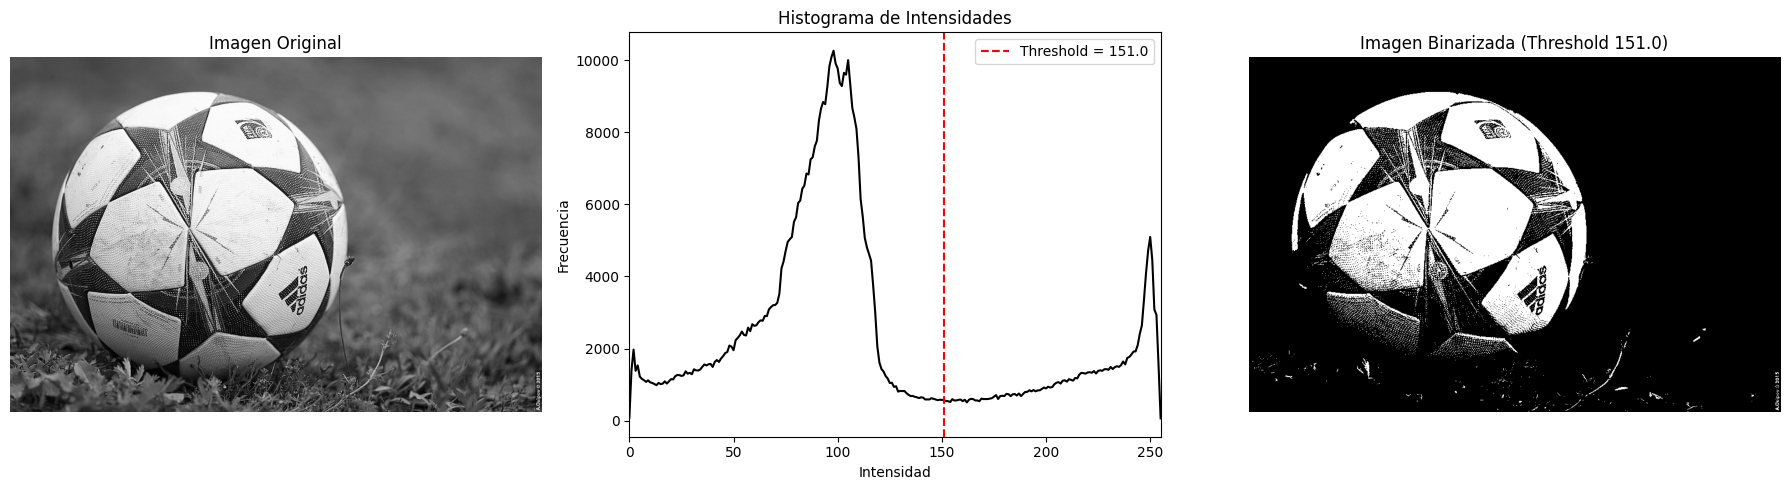

In [26]:
from PIL import Image 
#! pip install opencv-python
import cv2 # pip install opencv-python

''' 
Algoritmo OTSU: Calcular el threshold de manera automatica 
Maximizar la varianza entre los rangos de valores de pixeles
'''
img = Image.open('p_fut.jpg').convert('L')
img_np = np.array(img)

hist = np.histogram(img_np, bins=256, range=(0, 255))[0]

threshold, mat = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

binary_img = mat 
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(img_np, cmap='gray')
axs[0].set_title("Imagen Original")
axs[0].axis('off')

axs[1].plot(hist, color='black')
axs[1].axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
axs[1].set_title('Histograma de Intensidades')
axs[1].legend()
axs[1].set_xlim(0, 255)
axs[1].set_ylabel('Frecuencia')
axs[1].set_xlabel('Intensidad')

axs[2].imshow(binary_img, cmap='gray')
axs[2].set_title(f'Imagen Binarizada (Threshold {threshold})')
axs[2].axis('off')

plt.tight_layout()
plt.show()


Los dos tresholds adaptativos, mean y gaussian, mejoran mucho los resultados. Solo necesitamos experimentar con los block sizes y C para preservar la forma a la vez que intentamos suprimir lo máximo posible la parte del pasto.

(np.float64(-0.5), np.float64(959.5), np.float64(639.5), np.float64(-0.5))

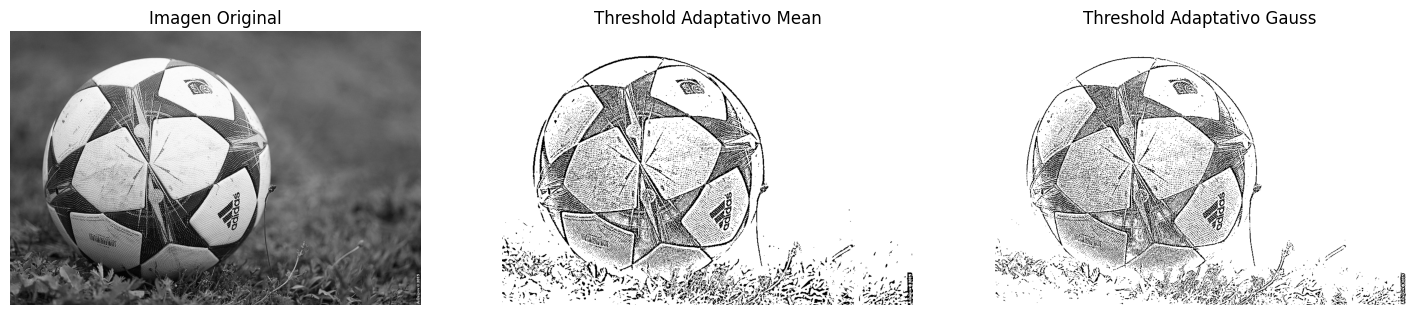

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].imshow(img_np, cmap='gray')
axs[0].set_title("Imagen Original")
axs[0].axis('off')

binary_img = cv2.adaptiveThreshold(img_np, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, blockSize=11, C=15)
axs[1].imshow(binary_img, cmap='gray')
axs[1].set_title('Threshold Adaptativo Mean')
axs[1].axis('off')

binary_img = cv2.adaptiveThreshold(img_np, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=11, C=15)
axs[2].imshow(binary_img, cmap='gray')
axs[2].set_title('Threshold Adaptativo Gauss')
axs[2].axis('off')

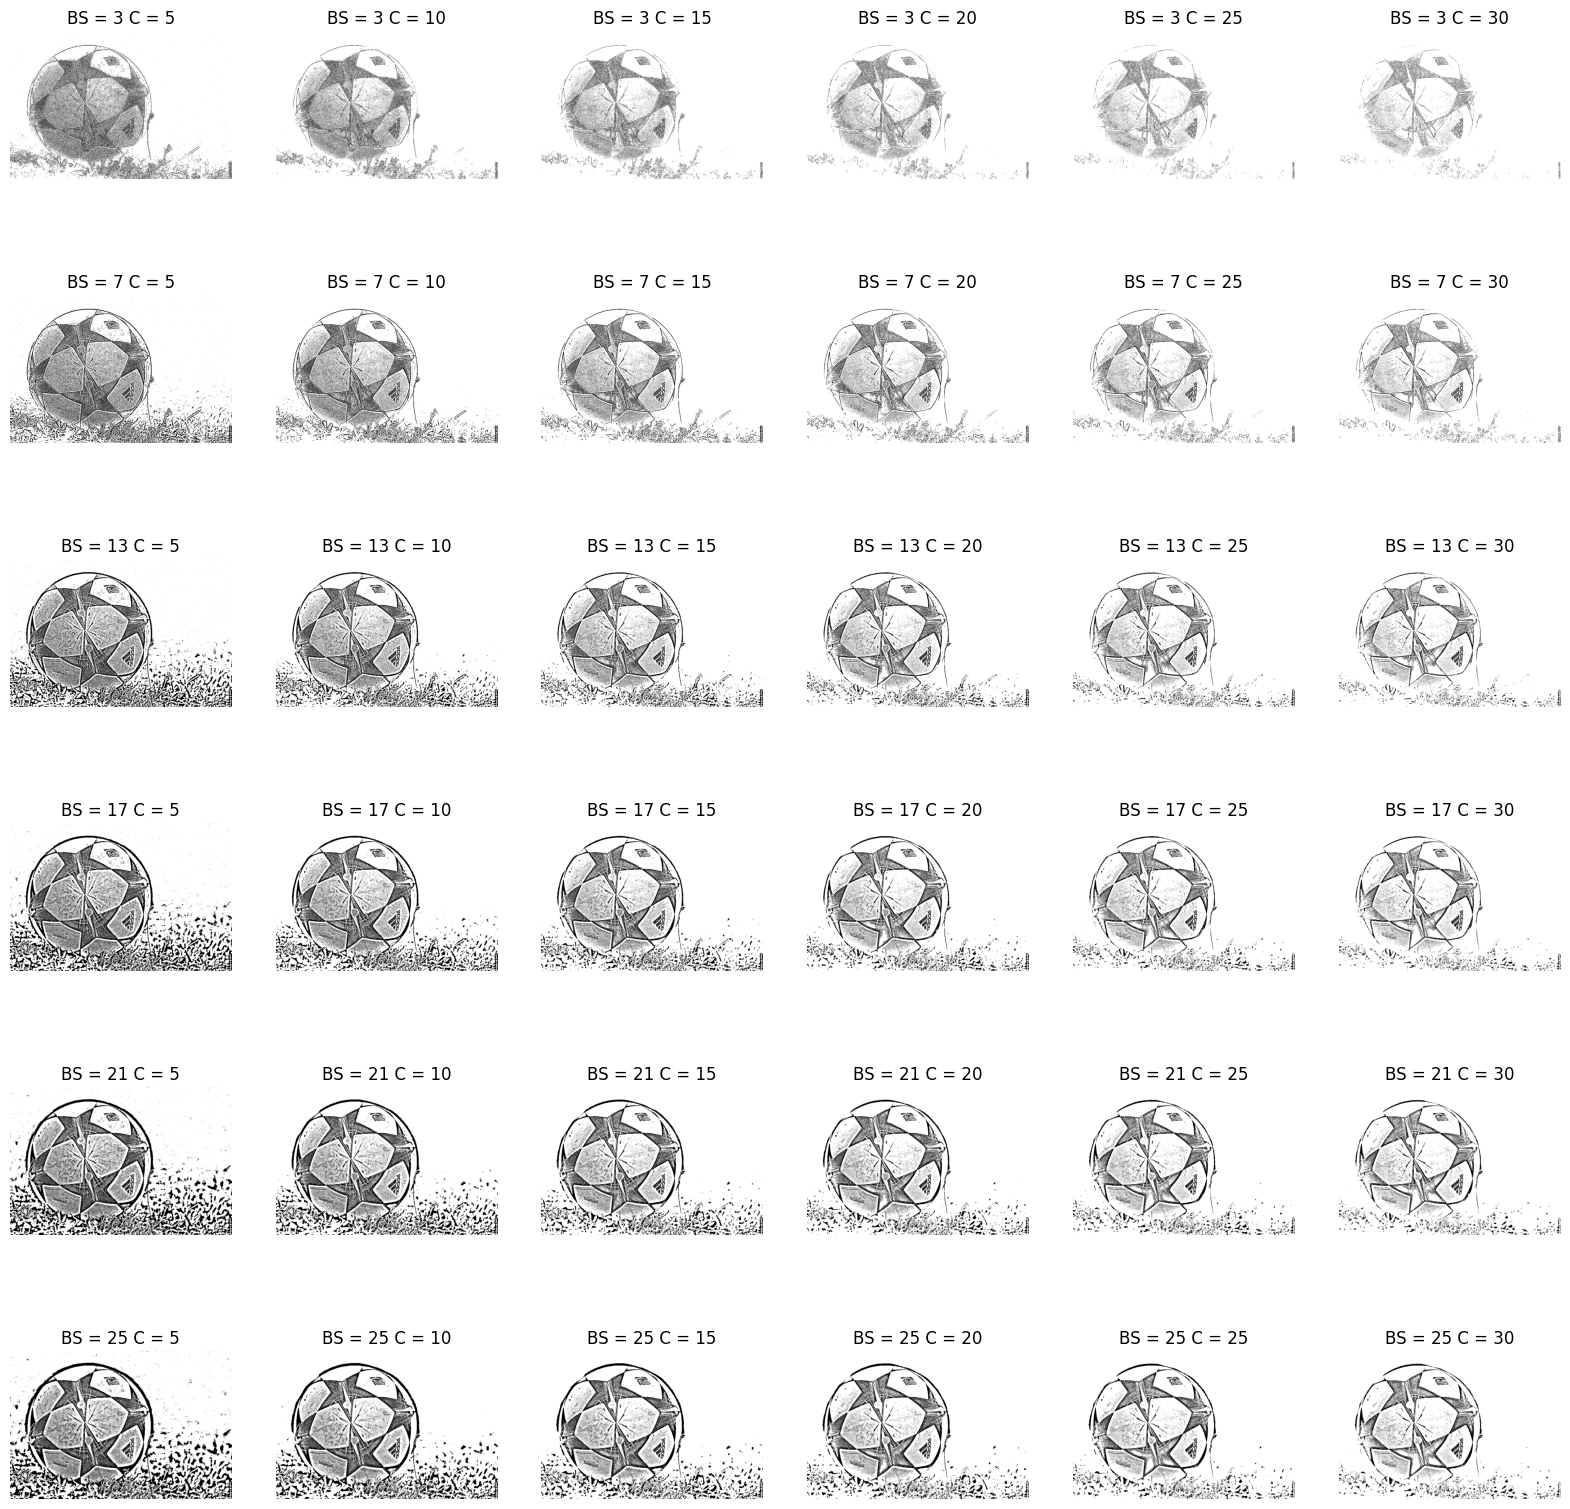

In [28]:
blockSizes = (3, 7, 13, 17, 21, 25)
constantes = (5, 10, 15, 20, 25, 30)

parametros = list(itertools.product(blockSizes, constantes))

fig, axs = plt.subplots(nrows=6, ncols=6, figsize=(20, 20))
axs = axs.flatten()

for i, (blockSize, constante) in enumerate(parametros):
    binary_img = cv2.adaptiveThreshold(
        img_np,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        blockSize=blockSize,
        C=constante,
    )
    axs[i].imshow(binary_img, cmap="gray")
    axs[i].set_title(f"BS = {blockSize} C = {constante}")
    axs[i].axis("off")  

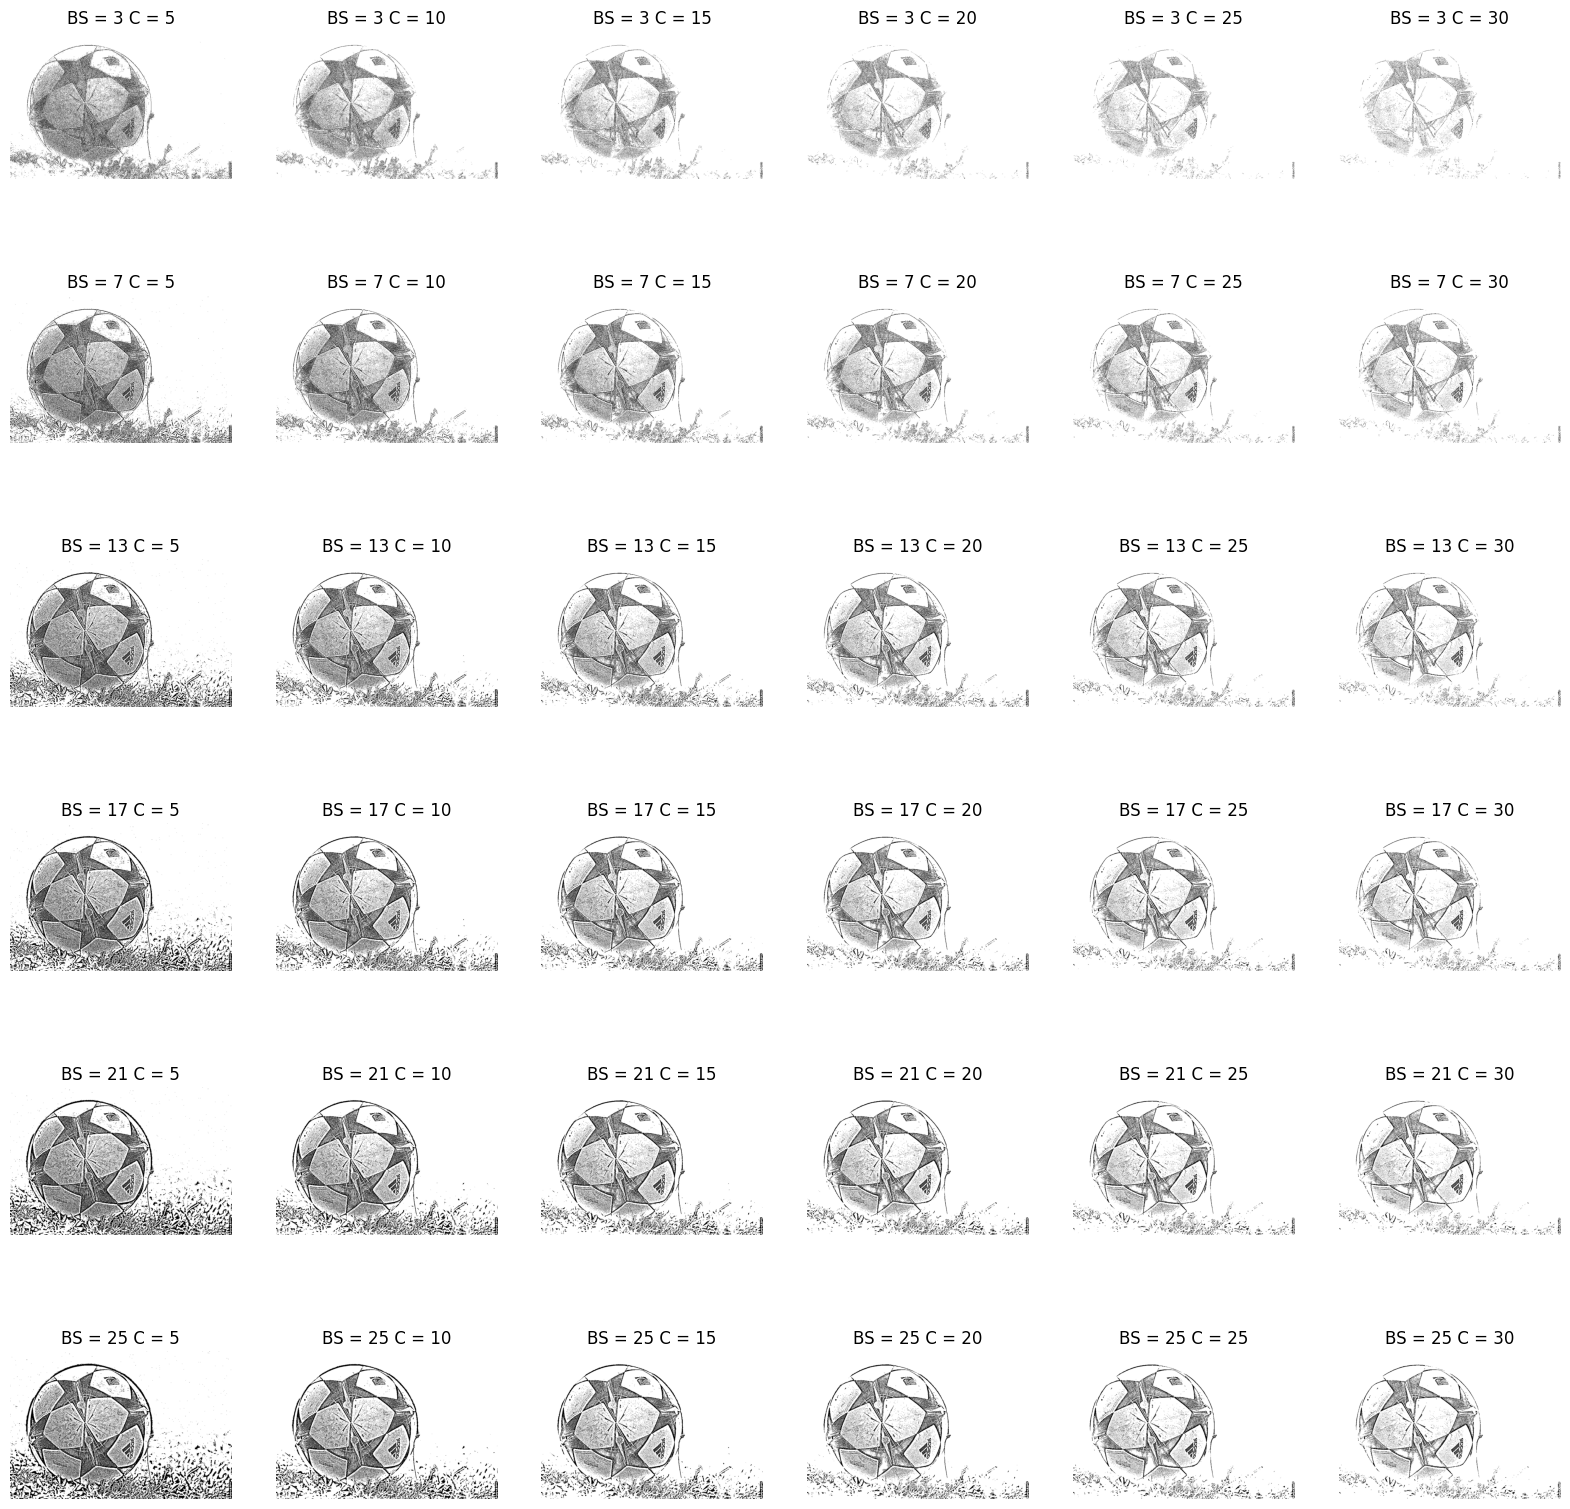

In [29]:
fig, axs = plt.subplots(nrows=6, ncols=6, figsize=(20, 20))
axs = axs.flatten()

for i, (blockSize, constante) in enumerate(parametros):
    binary_img = cv2.adaptiveThreshold(
        img_np,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=blockSize,
        C=constante,
    )
    axs[i].imshow(binary_img, cmap="gray")
    axs[i].set_title(f"BS = {blockSize} C = {constante}")
    axs[i].axis("off")

Inspeccionando visualmente, los mejores resultados se dan con BS = 25 y C = 10 con el gaussian adaptive, que podemos combinar con una eliminación manual del pasto (treshold geográfico).

(np.float64(-0.5), np.float64(959.5), np.float64(639.5), np.float64(-0.5))

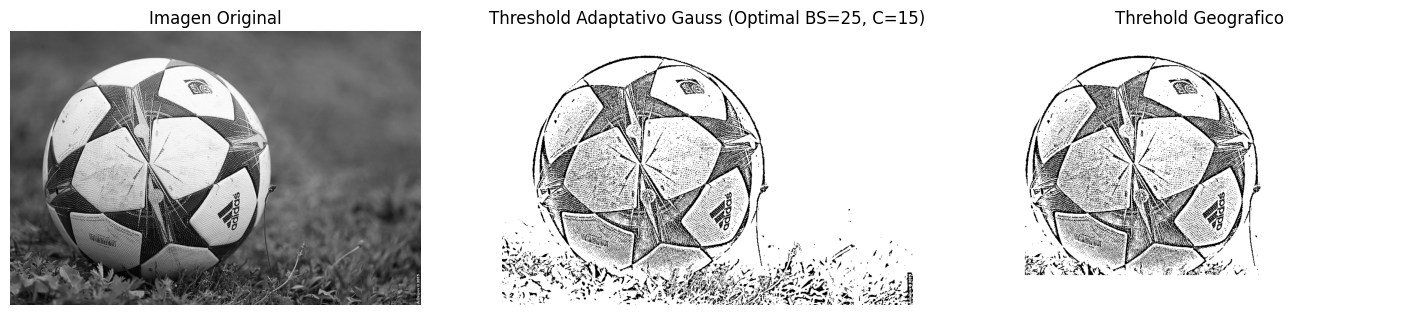

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].imshow(img_np, cmap="gray")
axs[0].set_title("Imagen Original")
axs[0].axis("off")

optimal_bs = 25
optimal_C = 15
binary_img = cv2.adaptiveThreshold(
    img_np,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=optimal_bs,
    C=optimal_C,
)
axs[1].imshow(binary_img, cmap="gray")
axs[1].set_title(f"Threshold Adaptativo Gauss (Optimal BS={optimal_bs}, C={optimal_C})")
axs[1].axis("off")

manual_cut_img = binary_img.copy()
manual_cut_img[570:, :] = 255
manual_cut_img[:, :70] = 255
manual_cut_img[:, 620:] = 255

axs[2].imshow(manual_cut_img, cmap='gray')
axs[2].set_title('Threhold Geografico')
axs[2].axis('off')